# Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time

### Function

In [ ]:
def generate_points(start=-5.0, end=5.0, size=1000):
    x_values = np.linspace(start, end, size)
    y_values = np.cos(3*np.sin(x_values))
    np.random.seed(42)
    noise = 0.2 * np.random.randn(len(x_values))
    noisy_y_values = y_values + noise
    return (x_values, noisy_y_values)

def plot_result(X, y, model, loss):
    x_values, noisy_y_values = X, y
    x_values = np.array(x_values).reshape(-1, 1)
    noisy_y_values = np.array(noisy_y_values)
    y_values = np.cos(3*np.sin(x_values)).flatten()

    x_t = torch.tensor(x_values, dtype=torch.float32)
    predicted_y_values = model(x_t).flatten()

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(x_values, noisy_y_values, label='Noisy Data', color='blue', s=10)
    plt.plot(x_values, y_values, label='True Data', color='red', linestyle='--')
    plt.plot(x_values, predicted_y_values.detach().numpy(), label='Model Prediction', color='orange')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Model Predictions vs True Data and Noisy Data')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Loss')
    plt.title('Loss over time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def simple_graph(X, y):
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y)
    plt.title("Function with Random Noise")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.show()

# HW

นายไซน์ มีข้อมูลอยู่ชุดหนึ่งที่สร้างจาก Function ที่เขาสนใจ แต่ข้อมูลนั้นดันมี noise ปะปนอยู่ด้วย ทำให้เขาไม่สามารถนำข้อมูลที่มีมาวาดเป็นกราฟเส้นได้ชัดเจน ดังภาพด้านล่าง

นายไซน์ ต้องการจะใช้ Neural networks มาเพื่อประมาณค่าข้อมูลที่มี แล้ววาดกราฟให้ได้มีความใกล้เคียงกับข้อมูลเดิมจาก Function ที่เขาสนใจมากที่สุด

จงสร้าง Neural Network Model ที่มีโครงสร้างตรงตามข้อกำหนดต่อไปนี้
1. มีจำนวน Nodes ภายใน Input/Output layer = 1
2. มีจำนวน Nodes ภายใน Hidden layer อยู่ในช่วง [1, 200]
3. มีจำนวน Hidden layer อยู่ในโครงสร้างในช่วง [1, 4] ชั้น
4. ใช้ Activation function หลัง Hidden layer ทุกครั้ง เช่น Tanh, Sigmoid, ReLU

ข้อกำหนด Hyperparameters
1. ใช้ Learning rate ในช่วง [0.1, 0.001]
2. ใช้จำนวนรอบการ Training (epoch) ในช่วง [100, 100000]

นายไซน์ ต้องการผลลัพธ์การประมาณให้ออกมาดีที่สุด โดยกำหนดให้ค่า Loss ต้องมีค่าต่ำกว่า 0.005

บันทึกผลลัพธ์การทำงาน ค่า Loss และภาพกราฟการประมาณที่ได้ จัดทำและส่งเป็น pdf


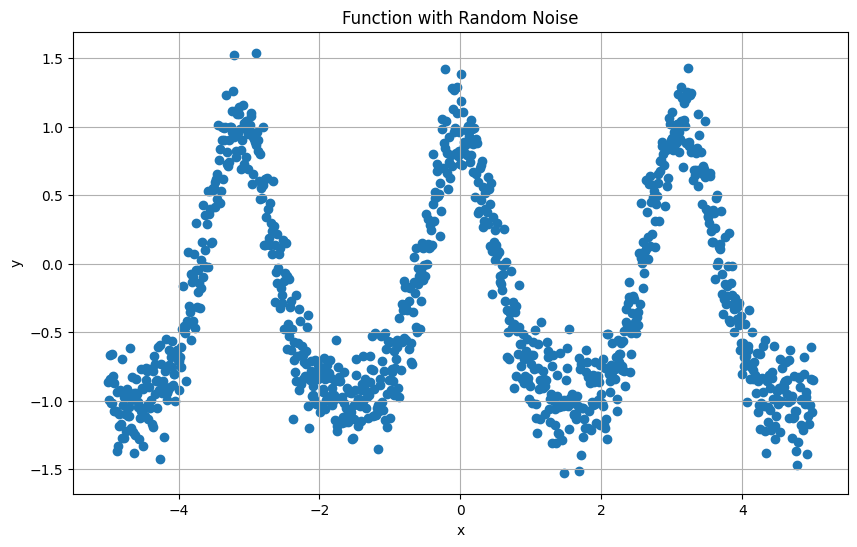

In [ ]:
# Sine's random data
X, y = generate_points()
simple_graph(X, y)

In [ ]:
# class Net(nn.Module):
#     def __init__(self, input_dim=1, output_dim=1):
#         super(Net, self).__init__()
#         self.layers = nn.Sequential(
#             # nn.Linear(input_dim, ...), # <--
#             # nn.Activation...(), # <--
#             # ...
#             # nn.Linear(..., output_dim) # <--
#         )

#     def forward(self, x):
#         return self.layers(x)

# # Hyperparameters
# lr = 1e-3 # <--
# num_epochs = 1000 # <--

In [ ]:
# import torch.optim as optim
# # Convert to PyTorch tensors
# X_tensor = torch.from_numpy(X).float().view(-1, 1)
# y_tensor = torch.from_numpy(y).float().view(-1, 1)

# # Init model
# model = Net()

# # Loss and optimizer
# criterion = nn.MSELoss()
# optimizer = optim.SGD(model.parameters(), lr=lr)

# n_show_loss = num_epochs // 10
# training_loss = []
# t_0 = time.time()
# model.train(True)
# # Begin training loop
# for epoch in range(num_epochs):
#     y_pred = model(X_tensor)
#     loss = criterion(y_pred, y_tensor)
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

#     training_loss.append(loss.item())
#     if ((epoch+1) % n_show_loss == 0) or (epoch == num_epochs-1):
#         print(f"Epochs {epoch+1}".ljust(12), f"train loss {loss.item()}")

# t_end = time.time()-t_0
# print(f"Time consumption training: {t_end} sec")

In [ ]:
# plot_result(X, y, model, training_loss)

# เฉลย

In [ ]:
class Net(nn.Module):
    def __init__(self, input_dim=1, output_dim=1):
        super(Net, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 150),
            nn.ReLU(),
            nn.Linear(150, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

# Hyperparameters
lr = 5e-3
num_epochs = 100000

In [33]:
# Convert to PyTorch tensors
X_tensor = torch.from_numpy(X).float().view(-1, 1)
y_tensor = torch.from_numpy(y).float().view(-1, 1)

# Init model
model = Net()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

n_show_loss = num_epochs // 10
training_loss = []
t_0 = time.time()
model.train(True)
# Begin training loop
for epoch in range(num_epochs):
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    training_loss.append(loss.item())
    if ((epoch+1) % n_show_loss == 0) or (epoch == num_epochs-1):
        print(f"Epochs {epoch+1}".ljust(12), f"train loss {loss.item()}")

t_end = time.time()-t_0
print(f"Time consumption training: {t_end} sec")

Epochs 10000 train loss 0.04220082610845566
Epochs 20000 train loss 0.03774454444646835
Epochs 30000 train loss 0.03756384924054146
Epochs 40000 train loss 0.03708501532673836
Epochs 50000 train loss 0.0371306911110878
Epochs 60000 train loss 0.0368630588054657
Epochs 70000 train loss 0.03659263625741005
Epochs 80000 train loss 0.036522187292575836
Epochs 90000 train loss 0.03658159077167511
Epochs 100000 train loss 0.03638533875346184
Time consumption training: 943.0245213508606 sec


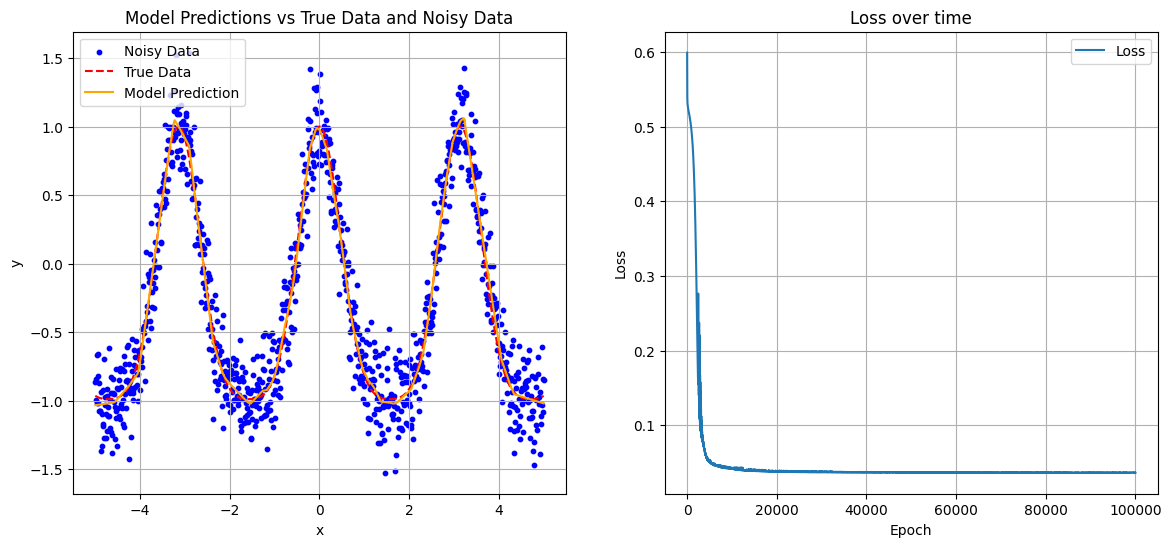

In [34]:
plot_result(X, y, model, training_loss)